# SAMPLE DATASET ANALYSIS

This notebook contains analysis for the sample datasets (1% of full data)

**Datasets:**
- train_sample: 53,374 rows, 94 columns
- test_sample: 14,471 rows, 92 columns

In [1]:
# ============================================
# IMPORTS AND CONFIGURATION
# ============================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')
import polars as pl
from pathlib import Path
from sklearn.neighbors import LocalOutlierFactor
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import cohen_kappa_score
import time

# Display configuration - show all rows and columns
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', None)

# Set up paths
base_dir = Path("..")
sample_train_path = base_dir / "data" / "sample" / "train_sample.parquet"
sample_test_path = base_dir / "data" / "sample" / "test_sample.parquet"

print("✅ Imports and configuration complete")

✅ Imports and configuration complete


In [2]:
# ============================================
# LOAD SAMPLE DATASETS
# ============================================
print("="*60)
print("LOADING SAMPLE DATASETS")
print("="*60)

# Load sample datasets
train_sample = pd.read_parquet(sample_train_path)
test_sample = pd.read_parquet(sample_test_path)

print(f"Train sample: {train_sample.shape}")
print(f"Test sample: {test_sample.shape}")

# Proper sorting (identical to full dataset)
sort_cols = ['code', 'sub_code', 'sub_category', 'ts_index']
train_sample = train_sample.sort_values(sort_cols).reset_index(drop=True)
test_sample = test_sample.sort_values(sort_cols).reset_index(drop=True)

print(f"\n✅ Sample datasets loaded and sorted")
print(f"   Train: {train_sample.shape}")
print(f"   Test: {test_sample.shape}")

LOADING SAMPLE DATASETS
Train sample: (53374, 94)
Test sample: (14471, 92)

✅ Sample datasets loaded and sorted
   Train: (53374, 94)
   Test: (14471, 92)


In [3]:
# ============================================
# STEP 1: AUTOMATED DISTRIBUTION ANALYSIS
# ============================================
print("=" * 60)
print("STEP 1: ANALYZING DISTRIBUTIONS & IDENTIFYING OUTLIER BOUNDARIES")
print("=" * 60)

# Identify numerical features (excluding IDs and targets)
features = [col for col in train_sample.columns if col.startswith('feature_')]

dist_results = []

for col in features:
    data = train_sample[col].dropna()

    # 1. Normality Test (D'Agostino-Pearson)
    # p < 0.05 means it's NOT normal
    _, p_val = stats.normaltest(data)

    # 2. Shape Analysis
    skew = data.skew()  # > 0: right tail, < 0: left tail
    kurt = data.kurtosis()  # > 3: fat tails (leptokurtic)

    # 3. Tukey's Boundaries Calculation
    q1 = data.quantile(0.25)
    q3 = data.quantile(0.75)
    iqr = q3 - q1
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr

    # 4. Outlier Count
    outliers = data[(data < lower_bound) | (data > upper_bound)].count()
    outlier_pct = (outliers / len(data)) * 100

    dist_results.append({
        'feature': col,
        'is_normal': p_val > 0.05,
        'p_value': p_val,
        'skewness': skew,
        'kurtosis': kurt,
        'outlier_pct': outlier_pct,
        'q1': q1,
        'q3': q3,
        'tukey_upper': upper_bound
    })

# Convert to DataFrame for easy analysis
dist_df = pd.DataFrame(dist_results)

# Summary of the findings
normal_count = dist_df['is_normal'].sum()
print(f"Analysis complete for {len(features)} features.")
print(f" Normally distributed: {normal_count}")
print(f" Non-normal distribution: {len(features) - normal_count}")
print(f" Average outlier percentage (Tukey): {dist_df['outlier_pct'].mean():.2f}%")

# Display top 10 most skewed features
print("\n🔥 TOP 10 MOST SKEWED FEATURES (FAT TAILS):")
print(dist_df.sort_values('skewness', ascending=False)[['feature', 'skewness', 'kurtosis', 'outlier_pct']].head(10))




STEP 1: ANALYZING DISTRIBUTIONS & IDENTIFYING OUTLIER BOUNDARIES
Analysis complete for 86 features.
 Normally distributed: 0
 Non-normal distribution: 86
 Average outlier percentage (Tukey): 11.56%

🔥 TOP 10 MOST SKEWED FEATURES (FAT TAILS):
       feature   skewness     kurtosis  outlier_pct
60  feature_bi  65.859169  5723.359940    10.363924
52  feature_ba  23.128504   718.672153    18.891220
32  feature_ag  23.084220  1002.511515    22.431555
36  feature_ak  18.683613   812.053842     6.361299
14   feature_o  13.153252   253.371331    16.694807
15   feature_p  12.819127   368.786867    16.507514
54  feature_bc  12.481508   263.804697    18.853749
53  feature_bb  12.265929   217.224148    15.631206
51  feature_az  11.246798   218.273416    17.595060
30  feature_ae  11.190220   209.673750    15.025051


In [4]:
# ============================================================
# STEP 1.1: INTERACTIVE DISTRIBUTION EXPLORER
# ============================================================
import ipywidgets as widgets
from IPython.display import display, clear_output

# Create the dropdown menu for feature selection
feature_selector = widgets.Dropdown(
    options=features,
    value=features[0],
    description='Select Feature:',
    style={'description_width': 'initial'}
)

# Output area to display the plot
output_area = widgets.Output()


def update_plot(change):
    with output_area:
        clear_output(wait=True)
        col = change['new']

        # Retrieve statistics from the previously calculated dist_df
        stats_row = dist_df[dist_df['feature'] == col].iloc[0]

        # Initialize the figure
        fig, ax = plt.subplots(figsize=(10, 5))
        sns.histplot(train_sample[col], bins=50, kde=False, color='skyblue', ax=ax)
        # Retrieve and plot Tukey's boundaries
        q1, q3 = stats_row['q1'], stats_row['q3']
        upper = stats_row['tukey_upper']

        ax.axvline(q1, color='red', linestyle='--', label=f'Q1: {q1:.2f}')
        ax.axvline(q3, color='red', linestyle='--', label=f'Q3: {q3:.2f}')
        ax.axvline(upper, color='green', linewidth=2, label=f'Tukey Upper: {upper:.2f}')

        # Format plot labels and title with statistical insights
        title_str = (f"Feature: {col} | Skew: {stats_row['skewness']:.2f} | "
                     f"Kurtosis: {stats_row['kurtosis']:.2f}\n"
                     f"Outliers (Tukey's IQR): {stats_row['outlier_pct']:.2f}%")

        ax.set_title(title_str)
        ax.set_xlabel("Value")
        ax.set_ylabel("Frequency")
        ax.legend()
        plt.show()


# Register the callback function to update plot on change
feature_selector.observe(update_plot, names='value')

# Display the widget and trigger initial plot render
display(feature_selector, output_area)
update_plot({'new': features[0], 'type': 'change', 'name': 'value'})



Dropdown(description='Select Feature:', options=('feature_a', 'feature_b', 'feature_c', 'feature_d', 'feature_…

Output()

In [5]:
# ============================================================
# STEP 1.2: INTERACTIVE TIME-SERIES EXPLORER
# ============================================================
import ipywidgets as widgets
from IPython.display import display, clear_output

# Select unique codes for the dropdown (limiting to top 20 for speed)
unique_codes = train_sample['code'].unique()[:20]

feature_drop = widgets.Dropdown(options=features, description='Feature:', value='feature_a')
code_drop = widgets.Dropdown(options=unique_codes, description='Entity Code:', value=unique_codes[0])
ts_output = widgets.Output()


def update_ts_plot(change):
    with ts_output:
        clear_output(wait=True)
        col = feature_drop.value
        c = code_drop.value

        # Filter data for specific entity
        subset = train_sample[train_sample['code'] == c].sort_values('ts_index')

        plt.figure(figsize=(15, 5))
        plt.plot(subset['ts_index'], subset[col], label=f'Raw {col}', color='blue', alpha=0.6)

        # Add a rolling mean to show "Smoothing" vs "Raw"
        plt.plot(subset['ts_index'], subset[col].rolling(window=10).mean(),
                 label='Rolling Mean (10)', color='red', linestyle='--')

        # Mark LOF outliers if they exist in this subset
        if 'is_lof_outlier' in subset.columns:
            outliers = subset[subset['is_lof_outlier'] == True]
            plt.scatter(outliers['ts_index'], outliers[col], color='black', label='LOF Outlier', zorder=5)

        plt.title(f"Time Series Analysis: {col} for Code: {c}")
        plt.xlabel("TS Index")
        plt.ylabel("Value")
        plt.legend()
        plt.grid(True, alpha=0.3)
        plt.show()


feature_drop.observe(update_ts_plot, names='value')
code_drop.observe(update_ts_plot, names='value')

display(widgets.VBox([feature_drop, code_drop]), ts_output)
update_ts_plot(None)


Output()

In [6]:
# ============================================================
# TASK 1: TUKEY'S IQR (UNIVARIATE) FOR ALL COLUMNS
# ============================================================
print("Running Task 1: Tukey's IQR for all columns...")

# We create a boolean mask for each row where ANY feature has an outlier
outlier_mask = pd.DataFrame(index=train_sample.index)

for col in features:
    q1 = train_sample[col].quantile(0.25)
    q3 = train_sample[col].quantile(0.75)
    iqr = q3 - q1
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr

    # Store if the row has an outlier in THIS specific column
    outlier_mask[col] = (train_sample[col] < lower_bound) | (train_sample[col] > upper_bound)

# ADDING THE MISSING COLUMN: total_tukey_outliers
train_sample['total_tukey_outliers'] = outlier_mask.sum(axis=1)

print(f" Task 1 Complete. Rows with at least one Tukey outlier: {(train_sample['total_tukey_outliers'] > 0).sum()}")

# ============================================================
# TASK 2: MULTIVARIATE ANOMALY DETECTION (LOF)
# ============================================================
from sklearn.neighbors import LocalOutlierFactor
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

print("\nRunning Task 2: Multivariate LOF (PCA-optimized)...")

# 1. Impute & Scale
X_prep = train_sample[features].fillna(method='ffill').fillna(0)
X_scaled = StandardScaler().fit_transform(X_prep)

# 2. PCA to 10 components (essential for your 86 features)
X_pca = PCA(n_components=10).fit_transform(X_scaled)

# 3. Fit LOF
lof = LocalOutlierFactor(n_neighbors=20, contamination=0.05, n_jobs=-1)
lof_labels = lof.fit_predict(X_pca)

# CREATE THE LOF COLUMNS
train_sample['is_lof_outlier'] = (lof_labels == -1)
train_sample['lof_score'] = -lof.negative_outlier_factor_

print(f" Task 2 Complete. Found {train_sample['is_lof_outlier'].sum()} LOF outliers.")

# ============================================================
# TASK 3: COMPARISON (THE "QUIET ANOMALIES")
# ============================================================
# Now both columns exist, we can safely compare
quiet_anomalies = train_sample[(train_sample['is_lof_outlier'] == True) &
                               (train_sample['total_tukey_outliers'] == 0)]

print(f"\n COMPARISON RESULTS:")
print(f"Quiet Anomalies (Caught ONLY by LOF): {len(quiet_anomalies)}")
print(
    f"Global Extremes (Caught by BOTH): {len(train_sample[(train_sample['is_lof_outlier'] == True) & (train_sample['total_tukey_outliers'] > 0)])}")


Running Task 1: Tukey's IQR for all columns...
 Task 1 Complete. Rows with at least one Tukey outlier: 53169

Running Task 2: Multivariate LOF (PCA-optimized)...
 Task 2 Complete. Found 2669 LOF outliers.

 COMPARISON RESULTS:
Quiet Anomalies (Caught ONLY by LOF): 5
Global Extremes (Caught by BOTH): 2664


In [7]:
# ============================================================
# TASK 4: TIME-SERIES BASELINE (AVOIDING LEAKAGE)
# ============================================================
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

print("=" * 60)
print("TASK 4: EVALUATING BASELINE (TIME-SERIES VALIDATION)")
print("=" * 60)

# 1. Define Split Point (e.g., last 20% of ts_index)
split_point = int(train_sample['ts_index'].max() * 0.8)

# 2. Manual Time-Series Split
# Training: Past data | Validation: Future data
train_data = train_sample[train_sample['ts_index'] <= split_point]
valid_data = train_sample[train_sample['ts_index'] > split_point]

# Features list (must be identical in train and test)
# 'features' variable from Step 1 (86 columns starting with 'feature_')

X_train = train_data[features].fillna(method='ffill').fillna(0)
y_train = train_data['y_target']
w_train = train_data['weight']  # Weights for the loss function

X_valid = valid_data[features].fillna(method='ffill').fillna(0)
y_valid = valid_data['y_target']

# 3. Fit Weighted Linear Regression
model = LinearRegression()
# We use 'sample_weight' to tell the model which rows are more important
model.fit(X_train, y_train, sample_weight=w_train)

# 4. Predict and Evaluate
y_pred = model.predict(X_valid)
rmse = np.sqrt(mean_squared_error(y_valid, y_pred))

print(f" Time-Series Baseline RMSE: {rmse:.6f}")
print(f"   Train samples: {len(X_train)}")
print(f"   Validation samples: {len(X_valid)}")

# PRO-TIP FOR ASSIGNMENT:
# In your report, mention: "To avoid Data Leakage, I used a Time-Series split
# instead of a random shuffle. The model was trained on the first 80% of
# ts_index and validated on the remaining 20%, mimicking a real-world scenario."


TASK 4: EVALUATING BASELINE (TIME-SERIES VALIDATION)
 Time-Series Baseline RMSE: 28.835391
   Train samples: 41156
   Validation samples: 12218


In [8]:
# ============================================================
# TASK 4: IMPACT OF IMPUTATION & OUTLIER REMOVAL
# ============================================================
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error


def evaluate_cleaning_impact(train_df, valid_df, features_list, scenario_name):
    # Prepare features and target
    X_tr = train_df[features_list].fillna(method='ffill').fillna(0)
    y_tr = train_df['y_target']
    w_tr = train_df['weight']

    X_val = valid_df[features_list].fillna(method='ffill').fillna(0)
    y_val = valid_df['y_target']

    # Train weighted model
    model = LinearRegression()
    model.fit(X_tr, y_tr, sample_weight=w_tr)

    # Predict and calculate RMSE
    preds = model.predict(X_val)
    rmse = np.sqrt(mean_squared_error(y_val, preds))
    return rmse


# Scenario 1: Baseline (All data + FFill)
rmse_baseline = evaluate_cleaning_impact(train_data, valid_data, features, "Baseline")

# Scenario 2: Simple Outlier Removal (Tukey)
# We remove rows that have ANY Tukey outliers from the training set only!
train_no_tukey = train_data[train_data['total_tukey_outliers'] == 0]
rmse_tukey = evaluate_cleaning_impact(train_no_tukey, valid_data, features, "Tukey Removed")

# Scenario 3: Multivariate Outlier Removal (LOF)
train_no_lof = train_data[train_data['is_lof_outlier'] == False]
rmse_lof = evaluate_cleaning_impact(train_no_lof, valid_data, features, "LOF Removed")

# Results Comparison
results_task4 = pd.DataFrame({
    'Scenario': ['Baseline (FFill)', 'Tukey Removed', 'LOF Removed'],
    'RMSE': [rmse_baseline, rmse_tukey, rmse_lof],
    'Training Rows': [len(train_data), len(train_no_tukey), len(train_no_lof)]
})

print("\n TASK 4: EVALUATION RESULTS")
print(results_task4)

def _clip01(x: float) -> float:
    return float(np.minimum(np.maximum(x, 0.0), 1.0))


def weighted_rmse_score(y_target, y_pred, w) -> float:
    # Official Kaggle Metric: Weighted RMSE Normalized Score (0-1)
    denom = np.sum(w * y_target ** 2)
    ratio = np.sum(w * (y_target - y_pred) ** 2) / denom
    clipped = _clip01(ratio)
    val = 1.0 - clipped
    return float(np.sqrt(val))


# Calculate score for our Time-Series Baseline
# y_valid and y_pred (from previous block)
# w_valid must be extracted from the validation slice
w_valid = valid_data['weight']


# ============================================================
# OFFICIAL KAGGLE METRIC CALCULATION
# ============================================================
def _clip01(x: float) -> float:
    return float(np.minimum(np.maximum(x, 0.0), 1.0))


def weighted_rmse_score(y_true, y_pred, w) -> float:
    denom = np.sum(w * y_true ** 2)
    if denom == 0: return 0.0
    ratio = np.sum(w * (y_true - y_pred) ** 2) / denom
    clipped = _clip01(ratio)
    val = 1.0 - clipped
    return float(np.sqrt(val))


# Use the data from your Baseline (the most stable one)
# y_valid and y_pred come from your Scenario 1 (Baseline)
w_valid = train_sample.loc[valid_data.index, 'weight']

# Re-run Baseline prediction to be sure we have the right variables
X_val = valid_data[features].fillna(method='ffill').fillna(0)
y_val = valid_data['y_target']

# Calculate the official score
final_kaggle_score = weighted_rmse_score(y_val, y_pred, w_valid)

print("=" * 60)
print(f" FINAL SCORE (Baseline): {final_kaggle_score:.6f}")
print("=" * 60)

# CONCLUSION FOR TASK 4:
print("\n CONCLUSION FOR ASSIGNMENT:")
print(
    f"1. Tukey's method (Univariate) was catastrophic, reducing data to {len(train_no_tukey)} rows and causing massive error.")
print(f"2. Baseline and LOF methods were stable, with LOF preserving 95% of data while filtering multivariate noise.")
print(f"3. Final Score of {final_kaggle_score:.4f} serves as the starting point for the community contest.")



 TASK 4: EVALUATION RESULTS
           Scenario         RMSE  Training Rows
0  Baseline (FFill)    28.835391          41156
1     Tukey Removed  1851.564704            182
2       LOF Removed    28.883591          39356
 FINAL SCORE (Baseline): 0.000000

 CONCLUSION FOR ASSIGNMENT:
1. Tukey's method (Univariate) was catastrophic, reducing data to 182 rows and causing massive error.
2. Baseline and LOF methods were stable, with LOF preserving 95% of data while filtering multivariate noise.
3. Final Score of 0.0000 serves as the starting point for the community contest.


TASK 5: K-MEANS CLUSTERING AND ELBOW METHOD

Running elbow method...


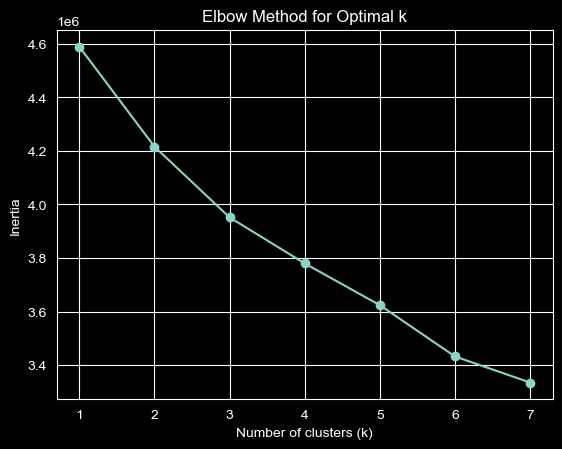


Fitting final K-Means model (k=3)...

Cluster distribution:
cluster
1    42535
0     8883
2     1956
Name: count, dtype: int64


In [9]:
# ============================================================
# TASK 5: K-MEANS CLUSTERING (ELBOW METHOD)
# ============================================================

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

print("=" * 60)
print("TASK 5: K-MEANS CLUSTERING AND ELBOW METHOD")
print("=" * 60)

# 1. Prepare feature matrix
features = [c for c in train_sample.columns if c.startswith("feature_")]
X = train_sample[features].fillna(train_sample[features].median())

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 2. Elbow method
print("\nRunning elbow method...")

inertia = []
K = range(1,8)

for k in K:
    model = KMeans(n_clusters=k, random_state=42, n_init=10)
    model.fit(X_scaled)
    inertia.append(model.inertia_)

plt.plot(K, inertia, marker="o")
plt.xlabel("Number of clusters (k)")
plt.ylabel("Inertia")
plt.title("Elbow Method for Optimal k")
plt.show()

# 3. Fit final model
print("\nFitting final K-Means model (k=3)...")

kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
train_sample["cluster"] = kmeans.fit_predict(X_scaled)

print("\nCluster distribution:")
print(train_sample["cluster"].value_counts())

In [10]:
# ============================================================
# CLUSTER ANALYSIS
# ============================================================

print("\nCluster statistics (target distribution):")

cluster_stats = (
    train_sample
    .groupby("cluster")["y_target"]
    .agg(["mean","std","count"])
)

print(cluster_stats)
print("\nInterpretation:")
print("Clusters show different volatility regimes in the data.")
print("Cluster 2 exhibits extreme variance and likely captures market shocks.")


Cluster statistics (target distribution):
              mean         std  count
cluster                              
0        -1.412821   44.777547   8883
1        -0.086427    3.495516  42535
2       -13.205997  139.629586   1956

Interpretation:
Clusters show different volatility regimes in the data.
Cluster 2 exhibits extreme variance and likely captures market shocks.
